In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import nltk
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from sklearn.model_selection import train_test_split , GridSearchCV , StratifiedKFold , cross_val_score
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay , accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import pickle
import re

In [3]:
data = pd.read_csv('amazon_alexa.tsv' , sep = '\t')

In [4]:
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [5]:
data.shape

(3150, 5)

In [6]:
data.columns

Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [8]:
data.columns.values

array(['rating', 'date', 'variation', 'verified_reviews', 'feedback'],
      dtype=object)

In [9]:
data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [10]:
data[data['verified_reviews'].isna() == True]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [11]:
data.dropna(inplace = True)

In [12]:
data.shape

(3149, 5)

In [13]:
data['length'] = data['verified_reviews'].apply(len)

In [14]:
data.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1,195
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,172
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


In [15]:
data.head(11)

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1,195
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,172
4,5,31-Jul-18,Charcoal Fabric,Music,1,5
5,5,31-Jul-18,Heather Gray Fabric,I received the echo as a gift. I needed anothe...,1,172
6,3,31-Jul-18,Sandstone Fabric,"Without having a cellphone, I cannot use many ...",1,365
7,5,31-Jul-18,Charcoal Fabric,I think this is the 5th one I've purchased. I'...,1,221
8,5,30-Jul-18,Heather Gray Fabric,looks great,1,11
9,5,30-Jul-18,Heather Gray Fabric,Love it! I’ve listened to songs I haven’t hear...,1,114


In [16]:
data.iloc[10]

rating                                                              5
date                                                        30-Jul-18
variation                                            Charcoal Fabric 
verified_reviews    I sent it to my 85 year old Dad, and he talks ...
feedback                                                            1
length                                                             63
Name: 10, dtype: object

In [17]:
data.iloc[10]['length']

np.int64(63)

In [18]:
data.iloc[10]['verified_reviews']

'I sent it to my 85 year old Dad, and he talks to it constantly.'

In [19]:
data.dtypes

rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
length               int64
dtype: object

In [20]:
#analyzing  the rating counts

data['rating'].value_counts()

rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64

In [21]:
rating_2_reviews = data[data['rating'] == 2]

In [22]:
rating_2_reviews.head(10)

,rating,date,variation,verified_reviews,feedback,length
46,2,30-Jul-18,Charcoal Fabric,"It's like Siri, in fact, Siri answers more acc...",0,163
111,2,30-Jul-18,Charcoal Fabric,Sound is terrible if u want good music too get...,0,53
176,2,30-Jul-18,Heather Gray Fabric,Sad joke. Worthless.,0,20
187,2,29-Jul-18,Charcoal Fabric,Really disappointed Alexa has to be plug-in to...,0,338
205,2,29-Jul-18,Sandstone Fabric,It's got great sound and bass but it doesn't w...,0,114
233,2,29-Jul-18,Sandstone Fabric,I am not super impressed with Alexa. When my P...,0,307
299,2,29-Jul-18,Charcoal Fabric,Too difficult to set up. It keeps timing out ...,0,79
376,2,26-Jul-18,Black,Doesn't always respond when spoken to with pro...,0,159
382,2,25-Jul-18,Black,Poor quality. Gave it away.,0,27
394,2,22-Jul-18,White,"Initially, this echo dot worked very well. Ove...",0,272


[]

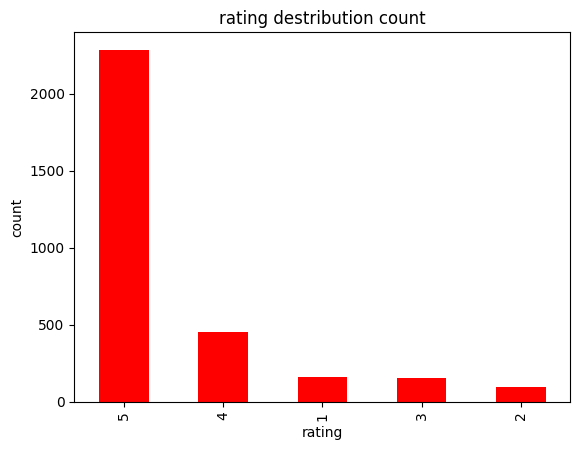

In [23]:
data['rating'].value_counts().plot.bar(color='red')
plt.title('rating destribution count')
plt.xlabel('rating')
plt.ylabel('count')
plt.plot()

In [24]:
data['rating'].value_counts(normalize=True).round(2)*100

rating
5    73.0
4    14.0
1     5.0
3     5.0
2     3.0
Name: proportion, dtype: float64

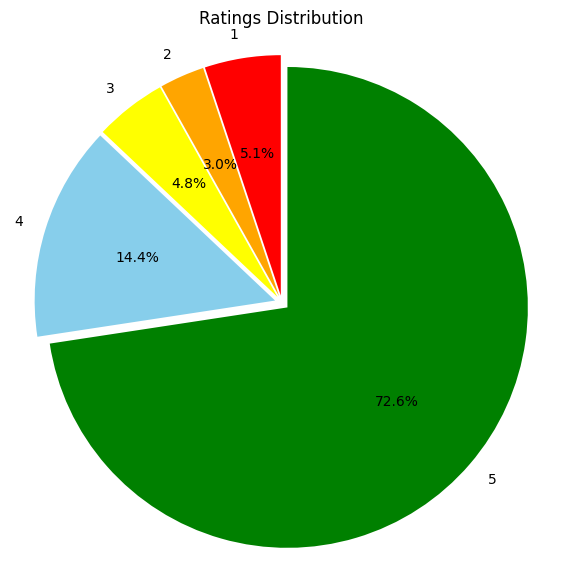

In [25]:
rating_counts = data['rating'].value_counts().sort_index()

colors = ['red', 'orange', 'yellow', 'skyblue', 'green']

plt.figure(figsize=(7,7))
plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.03]*len(rating_counts)
)

plt.title('Ratings Distribution')
plt.axis('equal')
plt.show()

In [26]:
data['feedback'].value_counts()

feedback
1    2893
0     256
Name: count, dtype: int64

In [27]:
data[data['feedback'] == 0].iloc[1]['verified_reviews']

'Sound is terrible if u want good music too get a bose'

In [28]:
data[data['feedback'] == 1].iloc[1]['verified_reviews']

'Loved it!'

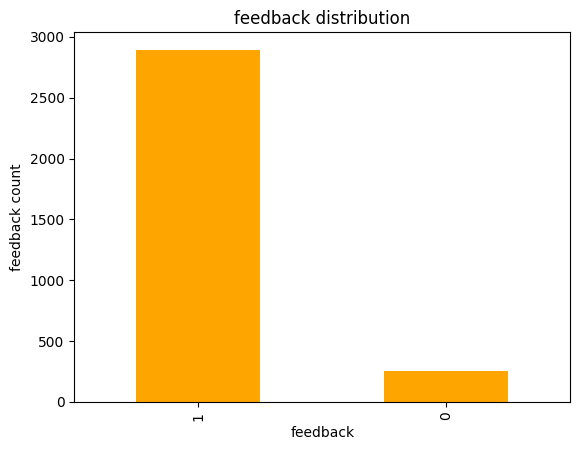

In [29]:
data['feedback'].value_counts().plot.bar(color='orange')
plt.title('feedback distribution')
plt.xlabel('feedback')
plt.ylabel('feedback count')
plt.show()

In [30]:
data['feedback'].value_counts(normalize = True).round(2)*100

feedback
1    92.0
0     8.0
Name: proportion, dtype: float64

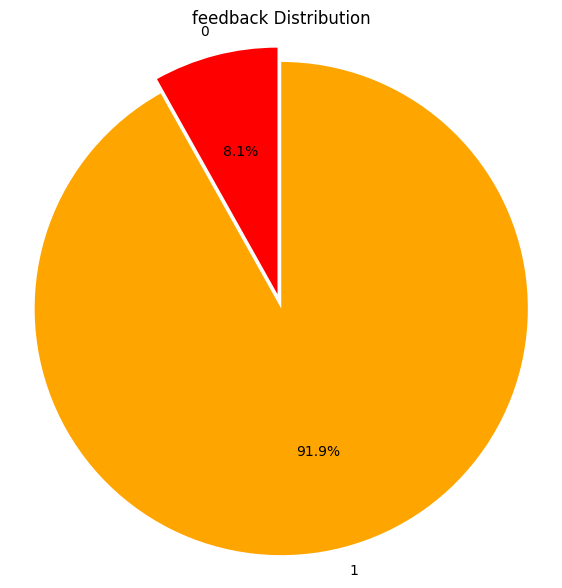

In [31]:
feedback_counts = data['feedback'].value_counts().sort_index()

colors = ['red', 'orange']

plt.figure(figsize=(7,7))
plt.pie(
    feedback_counts,
    labels=feedback_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.03]*len(feedback_counts)
)

plt.title('feedback Distribution')
plt.axis('equal')
plt.show()

In [32]:
data.columns

Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback',
       'length'],
      dtype='object')

In [33]:
data['variation'].value_counts()

variation
Black  Dot                      516
Charcoal Fabric                 430
Configuration: Fire TV Stick    350
Black  Plus                     270
Black  Show                     265
Black                           261
Black  Spot                     241
White  Dot                      184
Heather Gray Fabric             157
White  Spot                     109
Sandstone Fabric                 90
White                            90
White  Show                      85
White  Plus                      78
Oak Finish                       14
Walnut Finish                     9
Name: count, dtype: int64

<Axes: xlabel='variation'>

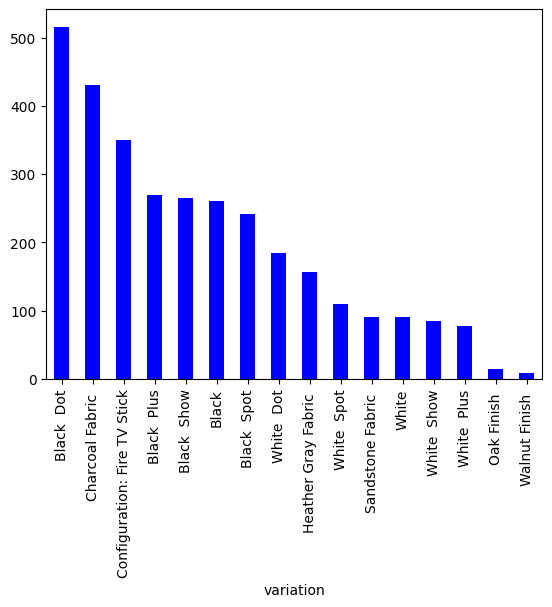

In [34]:
data['variation'].value_counts().plot.bar(color='blue')